2.3.1 Импорты и общие настройки. Использауется видяха

In [1]:
import os
import json
import pandas as pd
from pathlib import Path
import math
import random
from dataclasses import dataclass, asdict
from typing import Dict, Any, Tuple, Optional, List

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset

# Для Windows: num_workers=0 по умолчанию (чтобы избежать проблем с multiprocessing)
DEFAULT_NUM_WORKERS = 0

# Быстрый режим (рекомендуется для семинара/проверки)
FAST_MODE = True

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def maybe_subset(ds, max_items: Optional[int], seed: int = 42):
    if max_items is None:
        return ds
    n = len(ds)
    if max_items >= n:
        return ds
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=max_items, replace=False)
    return Subset(ds, idx.tolist())

set_seed(42)
device = get_device()
device

device(type='cuda')

In [2]:
def save_experiment_artifacts(
    experiment_id: str,
    model, 
    history: dict,
    es=None,
    test_metrics=None,
    dataset_name="EMNIST_balanced",
    seed=42,
    hidden_sizes=[512, 256, 128],
    dropout=0.0,
    use_batchnorm=False,
    optimizer_name="Adam",
    lr=1e-3,
    momentum=None,
    weight_decay=0.0,
    epochs_trained=None
):
    """Универсальная функция сохранения артефактов для всех экспериментов"""
    
    artifacts_dir = Path("artifacts")
    artifacts_dir.mkdir(parents=True, exist_ok=True)
    figures_dir = artifacts_dir / "figures"
    figures_dir.mkdir(exist_ok=True)
    
    # 1. runs.csv - строка эксперимента
    runs_row = {
        "experiment_id": experiment_id,
        "dataset": dataset_name,
        "seed": seed,
        "model_summary": f"MLP{hidden_sizes}/ReLU/dropout={dropout}/batchnorm={use_batchnorm}",
        "optimizer": optimizer_name,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "epochs_trained": epochs_trained or len(history["train_loss"]),
        "best_val_accuracy": es.best_score if es and hasattr(es, 'best_score') else max(history["val_acc"]),
        "best_val_loss": min(history["val_loss"])
    }
    
    runs_df = pd.DataFrame([runs_row])
    runs_csv_path = artifacts_dir / "runs.csv"
    if runs_csv_path.exists():
        runs_df.to_csv(runs_csv_path, mode='a', header=False, index=False)
    else:
        runs_df.to_csv(runs_csv_path, index=False)
    print(f"{experiment_id}: runs.csv обновлен")
    
    # 2. Для E4: best_model.pt + best_config.json
    if experiment_id == "E4":
        # Сохранение лучшей модели
        torch.save(model.state_dict(), artifacts_dir / "best_model.pt")
        
        # Сохранение конфига
        best_config = {
            "experiment_id": experiment_id,
            "dataset": dataset_name,
            "seed": seed,
            "model": "MLP",
            "hidden_sizes": hidden_sizes,
            "dropout": dropout,
            "use_batchnorm": use_batchnorm,
            "optimizer": optimizer_name,
            "lr": lr,
            "best_val_acc": runs_row["best_val_accuracy"],
            "epochs_trained": runs_row["epochs_trained"]
        }
        with open(artifacts_dir / "best_config.json", "w") as f:
            json.dump(best_config, f, indent=2)
        print(f"{experiment_id}: best_model.pt + best_config.json сохранены")
    
    # 3. График для лучшего эксперимента (E4) или LR extremes
    if experiment_id == "E4":
        fig_path = figures_dir / "curves_best.png"
    elif experiment_id == "O1":
        fig_path = figures_dir / "curves_lr_extremes.png"
    elif experiment_id == "O2":
        fig_path = figures_dir / "curves_lr_extremes2.png"
    else:
        return  
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"{experiment_id} Loss curves")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="train_acc")
    plt.plot(history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(f"{experiment_id} Accuracy curves")
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    

    # plt.show()  
    plt.close() 
    
    print(f"{experiment_id}: {fig_path} сохранен!")

2.3.2 Данные: EMNIST Balanced

In [3]:
def load_dataset(name: str = "KMNIST", fast_mode: bool = True):
    """Загружает датасет через torchvision. Если torchvision недоступен – fallback на sklearn digits."""
    try:
        import torchvision
        from torchvision import transforms
        from torchvision.datasets import EMNIST

        # лимиты под FAST_MODE
        max_train = 12000 if fast_mode else None
        max_test  = 3000 if fast_mode else None

        if name.upper() == "EMNIST_BALANCED":
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5,), (0.5,))
            ])
            ds_train = EMNIST(root="./data", split="balanced", train=True, download=True, transform=transform)
            ds_test  = EMNIST(root="./data", split="balanced", train=False, download=True, transform=transform)
            ds_train = maybe_subset(ds_train, max_train, seed=42)
            ds_test  = maybe_subset(ds_test, max_test, seed=43)
            input_shape = (1, 28, 28)
            num_classes = len(getattr(ds_train, "dataset", ds_train).classes)  # учитываем Subset
            return ds_train, ds_test, input_shape, num_classes, f"{name} (torchvision)"

        raise ValueError(f"Unknown dataset name: {name}")

    except Exception as e:
        print("torchvision недоступен или возникла ошибка загрузки. Fallback на sklearn.load_digits.")
        print("Причина:", repr(e))
        from sklearn.datasets import load_digits
        digits = load_digits()
        X = digits.images.astype(np.float32) / 16.0  # [0..1]
        y = digits.target.astype(np.int64)

        class DigitsDataset(torch.utils.data.Dataset):
            def __init__(self, X, y):
                self.X = torch.tensor(X).unsqueeze(1)  # (N,1,8,8)
                self.y = torch.tensor(y)
            def __len__(self): return self.X.shape[0]
            def __getitem__(self, idx): return self.X[idx], self.y[idx]

        ds_full = DigitsDataset(X, y)
        # split: 80/20
        n = len(ds_full)
        n_train = int(0.8 * n)
        n_test = n - n_train
        ds_train, ds_test = random_split(ds_full, [n_train, n_test], generator=torch.Generator().manual_seed(42))

        if fast_mode:
            ds_train = maybe_subset(ds_train, 1200, seed=42)
            ds_test  = maybe_subset(ds_test, 400, seed=43)

        input_shape = (1, 8, 8)
        num_classes = 10
        return ds_train, ds_test, input_shape, num_classes, "sklearn.load_digits (fallback)"

ds_train_full, ds_test, input_shape, num_classes, ds_name = load_dataset("EMNIST_BALANCED", fast_mode=FAST_MODE)
ds_name, input_shape, num_classes, len(ds_train_full), len(ds_test)

100%|███████████████████████████████████████████████████████████████████████████████| 562M/562M [00:16<00:00, 33.9MB/s]


Extracting ./data\EMNIST\raw\gzip.zip to ./data\EMNIST\raw


('EMNIST_BALANCED (torchvision)', (1, 28, 28), 47, 12000, 3000)

Разбиение train/val и DataLoader

In [4]:
def make_loaders(ds_train_full, ds_test, batch_size: int = 128, val_ratio: float = 0.2, seed: int = 42):
    n_total = len(ds_train_full)
    n_val = max(1, int(n_total * val_ratio))
    n_train = n_total - n_val

    gen = torch.Generator().manual_seed(seed)
    ds_train, ds_val = random_split(ds_train_full, [n_train, n_val], generator=gen)

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=DEFAULT_NUM_WORKERS, pin_memory=torch.cuda.is_available())
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=DEFAULT_NUM_WORKERS, pin_memory=torch.cuda.is_available())
    test_loader  = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=DEFAULT_NUM_WORKERS, pin_memory=torch.cuda.is_available())
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(ds_train_full, ds_test, batch_size=128)

# sanity-check
x, y = next(iter(train_loader))
x.shape, y.shape, x.min().item(), x.max().item()

(torch.Size([128, 1, 28, 28]), torch.Size([128]), -1.0, 1.0)

2.3.3. Модель MLP и цикл обучения

In [5]:
class MLP(nn.Module):
    def __init__(
        self,
        input_shape: Tuple[int, int, int],
        num_classes: int,
        hidden_sizes: List[int] = [256, 128],
        activation: str = "relu",
        use_batchnorm: bool = False,
        dropout: float = 0.0,
    ):
        super().__init__()
        c, h, w = input_shape
        in_features = c * h * w

        act_layer = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "gelu": nn.GELU,
        }.get(activation.lower(), nn.ReLU)

        layers: List[nn.Module] = [nn.Flatten()]

        prev = in_features
        for hs in hidden_sizes:
            layers.append(nn.Linear(prev, hs))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hs))
            layers.append(act_layer())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = hs

        layers.append(nn.Linear(prev, num_classes))  # logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [6]:
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def grad_global_norm(parameters) -> float:
    total_norm_sq = 0.0
    for p in parameters:
        if p.grad is None:
            continue
        param_norm = p.grad.data.norm(2).item()
        total_norm_sq += param_norm ** 2
    return math.sqrt(total_norm_sq)

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    max_grad_norm: Optional[float] = None,
    log_grad_norm: bool = False,
):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n = 0

    grad_norms_before = []
    grad_norms_after = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        # иногда на очень агрессивных настройках бывает NaN – делаем мягкую защиту
        if not torch.isfinite(loss):
            continue

        loss.backward()

        if log_grad_norm:
            gn_before = grad_global_norm(model.parameters())
            grad_norms_before.append(gn_before)

        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            if log_grad_norm:
                gn_after = grad_global_norm(model.parameters())
                grad_norms_after.append(gn_after)

        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs

    avg_loss = total_loss / max(1, n)
    avg_acc = total_acc / max(1, n)

    out = {"loss": float(avg_loss), "acc": float(avg_acc)}
    if log_grad_norm:
        out["grad_norm_before_mean"] = float(np.mean(grad_norms_before)) if grad_norms_before else None
        if max_grad_norm is not None:
            out["grad_norm_after_mean"] = float(np.mean(grad_norms_after)) if grad_norms_after else None
    return out

@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            continue
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs
    return {"loss": float(total_loss / max(1, n)), "acc": float(total_acc / max(1, n))}

def plot_history(history: Dict[str, List[float]], title: str = ""):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(list(epochs), history["train_loss"], label="train_loss")
    plt.plot(list(epochs), history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title or "Loss curves")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(list(epochs), history["train_acc"], label="train_acc")
    plt.plot(list(epochs), history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title or "Accuracy curves")
    plt.legend()
    plt.show()
def count_params(model: nn.Module) -> int:
  return sum(p.numel() for p in model.parameters() if p.requires_grad)


3. Эксперименты

3.1. Часть A (S08): регуляризация и переобучение

In [7]:
def fit(
    model, train_loader, val_loader, optimizer, criterion, device,
    epochs: int = 20, early_stopping=None, verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate(model, val_loader, criterion, device)

        tr_loss = train_metrics["loss"]
        tr_acc = train_metrics["acc"]
        va_loss = val_metrics["loss"]
        va_acc = val_metrics["acc"]

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(f"EarlyStopping: остановка на эпохе {epoch}. Лучший val_acc={early_stopping.best_score:.4f}")
                early_stopping.restore_best(model)
                break

    return history

epoch 01/20 | train loss=2.6208, acc=0.3082 | val loss=1.7729, acc=0.4792
epoch 02/20 | train loss=1.4611, acc=0.5717 | val loss=1.3429, acc=0.6058
epoch 03/20 | train loss=1.1887, acc=0.6434 | val loss=1.1580, acc=0.6521
epoch 04/20 | train loss=0.9977, acc=0.6878 | val loss=1.1462, acc=0.6525
epoch 05/20 | train loss=0.8630, acc=0.7327 | val loss=0.9688, acc=0.6950
epoch 06/20 | train loss=0.7532, acc=0.7591 | val loss=0.9047, acc=0.7083
epoch 07/20 | train loss=0.6685, acc=0.7818 | val loss=0.8950, acc=0.7113
epoch 08/20 | train loss=0.6115, acc=0.7990 | val loss=0.9030, acc=0.7288
epoch 09/20 | train loss=0.5516, acc=0.8153 | val loss=0.8613, acc=0.7342
epoch 10/20 | train loss=0.4976, acc=0.8307 | val loss=0.8477, acc=0.7300
epoch 11/20 | train loss=0.4494, acc=0.8481 | val loss=0.8210, acc=0.7346
epoch 12/20 | train loss=0.3954, acc=0.8625 | val loss=0.8534, acc=0.7238
epoch 13/20 | train loss=0.3697, acc=0.8685 | val loss=0.8466, acc=0.7350
epoch 14/20 | train loss=0.3210, acc=0

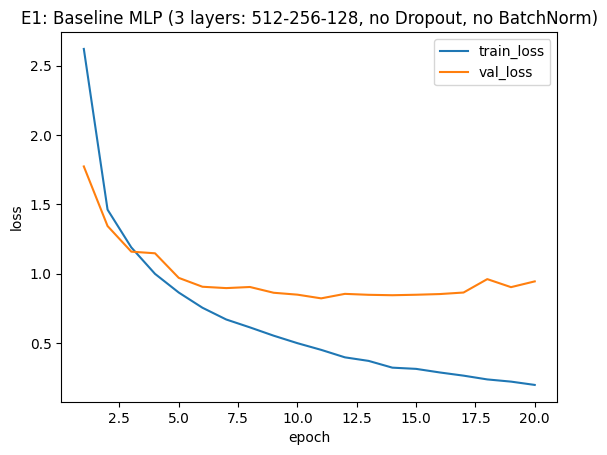

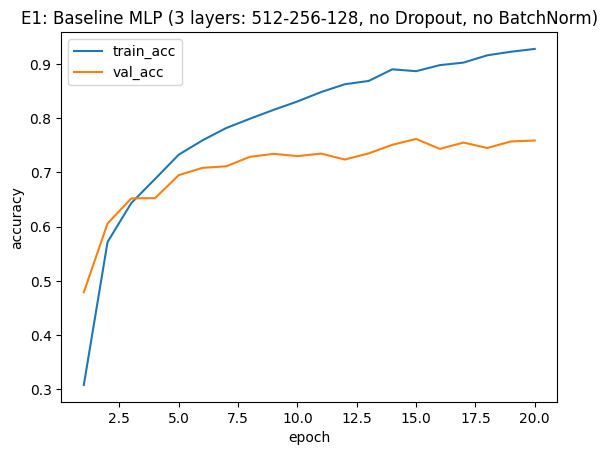

E1 test: loss=0.9576, acc=0.7560
E1: runs.csv обновлен


In [8]:
#E1
set_seed(42)

# E1 (base): MLP побольше (3 скрытых слоя вместо 2), без Dropout и без BatchNorm
baseline = MLP(
    input_shape=(1, 28, 28),        # EMNIST
    num_classes=47,                 # balanced
    hidden_sizes=[512, 256, 128],   # 3 слоя
    dropout=0.0,                    # без Dropout
    use_batchnorm=False             # без BatchNorm
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="E1: Baseline MLP (3 layers: 512-256-128, no Dropout, no BatchNorm)")
test_metrics_e1 = evaluate(baseline, test_loader, criterion, device)
print(f"E1 test: loss={test_metrics_e1['loss']:.4f}, acc={test_metrics_e1['acc']:.4f}")

save_experiment_artifacts(
    experiment_id="E1",
    model=baseline,
    history=history_baseline,
    dataset_name="EMNIST_balanced",
    seed=42,
    hidden_sizes=[512, 256, 128],
    dropout=0.0,
    use_batchnorm=False,
    optimizer_name="Adam",
    lr=1e-3
)

epoch 01/20 | train loss=3.2206, acc=0.1489 | val loss=2.1105, acc=0.4108
epoch 02/20 | train loss=2.0313, acc=0.4066 | val loss=1.4866, acc=0.5592
epoch 03/20 | train loss=1.6385, acc=0.5098 | val loss=1.2597, acc=0.6313
epoch 04/20 | train loss=1.4240, acc=0.5650 | val loss=1.1522, acc=0.6562
epoch 05/20 | train loss=1.2684, acc=0.6057 | val loss=1.0334, acc=0.6771
epoch 06/20 | train loss=1.1546, acc=0.6434 | val loss=0.9732, acc=0.6983
epoch 07/20 | train loss=1.0915, acc=0.6631 | val loss=0.9426, acc=0.7058
epoch 08/20 | train loss=1.0110, acc=0.6742 | val loss=0.8962, acc=0.7108
epoch 09/20 | train loss=0.9745, acc=0.6880 | val loss=0.8835, acc=0.7221
epoch 10/20 | train loss=0.9159, acc=0.7083 | val loss=0.8631, acc=0.7200
epoch 11/20 | train loss=0.8685, acc=0.7177 | val loss=0.8177, acc=0.7342
epoch 12/20 | train loss=0.8144, acc=0.7293 | val loss=0.8113, acc=0.7342
epoch 13/20 | train loss=0.8001, acc=0.7334 | val loss=0.7878, acc=0.7492
epoch 14/20 | train loss=0.7866, acc=0

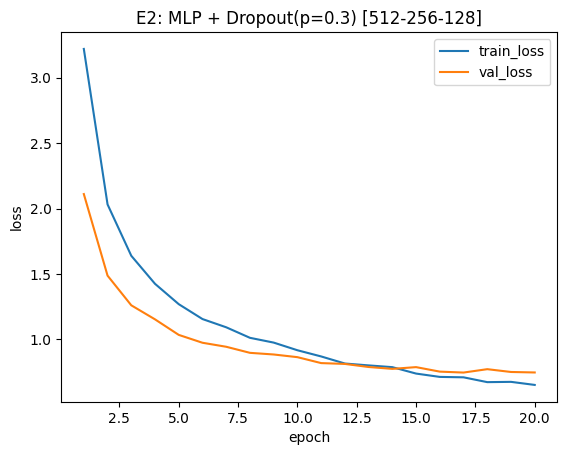

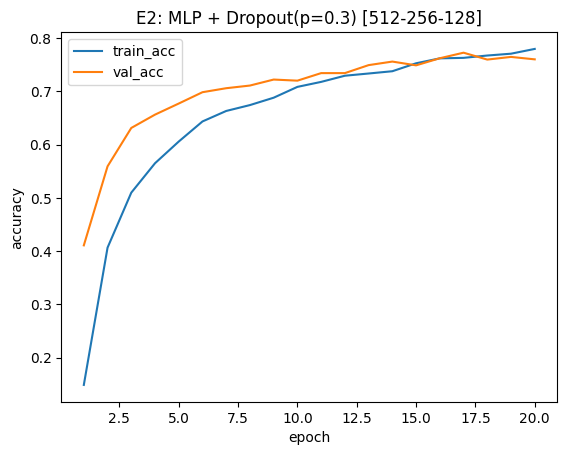

E2 Dropout test: loss=0.7431, acc=0.7693
E2: runs.csv обновлен


In [9]:
set_seed(42)

# E2 (Dropout): как E1, но Dropout p=0.3
dropout_model = MLP(
    input_shape=(1, 28, 28),
    num_classes=47,
    hidden_sizes=[512, 256, 128],   # Те же 3 слоя что в E1
    dropout=0.3,                    # Dropout p=0.3
    use_batchnorm=False             # Без BatchNorm
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout  = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="E2: MLP + Dropout(p=0.3) [512-256-128]")
test_metrics_e2 = evaluate(dropout_model, test_loader, criterion, device)
print(f"E2 Dropout test: loss={test_metrics_e2['loss']:.4f}, acc={test_metrics_e2['acc']:.4f}")

save_experiment_artifacts(
    experiment_id="E2",
    model=dropout_model,
    history=history_dropout,
    dataset_name="EMNIST_balanced", 
    seed=42,
    hidden_sizes=[512, 256, 128],
    dropout=0.3,
    use_batchnorm=False,
    optimizer_name="Adam",
    lr=1e-3
)

epoch 01/20 | train loss=2.1995, acc=0.5210 | val loss=1.4640, acc=0.6404
epoch 02/20 | train loss=1.0516, acc=0.7349 | val loss=1.0441, acc=0.7029
epoch 03/20 | train loss=0.6817, acc=0.8101 | val loss=0.8936, acc=0.7404
epoch 04/20 | train loss=0.4939, acc=0.8549 | val loss=0.8149, acc=0.7408
epoch 05/20 | train loss=0.3740, acc=0.8868 | val loss=0.7889, acc=0.7442
epoch 06/20 | train loss=0.2934, acc=0.9092 | val loss=0.7475, acc=0.7554
epoch 07/20 | train loss=0.2392, acc=0.9292 | val loss=0.7433, acc=0.7683
epoch 08/20 | train loss=0.2033, acc=0.9351 | val loss=0.7691, acc=0.7654
epoch 09/20 | train loss=0.1701, acc=0.9460 | val loss=0.7537, acc=0.7667
epoch 10/20 | train loss=0.1409, acc=0.9556 | val loss=0.8041, acc=0.7658
epoch 11/20 | train loss=0.1260, acc=0.9598 | val loss=0.7951, acc=0.7721
epoch 12/20 | train loss=0.1182, acc=0.9607 | val loss=0.8221, acc=0.7575
epoch 13/20 | train loss=0.1048, acc=0.9657 | val loss=0.8143, acc=0.7675
epoch 14/20 | train loss=0.0920, acc=0

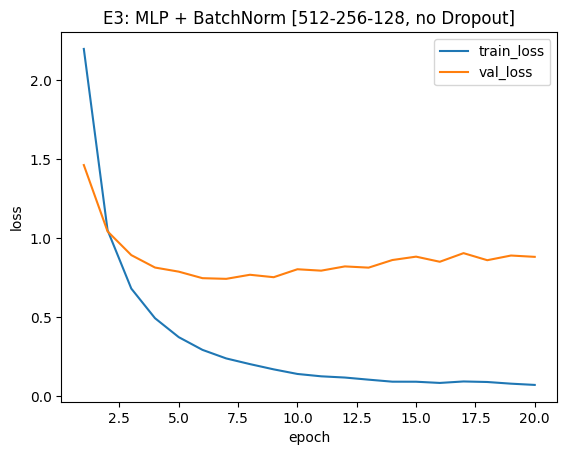

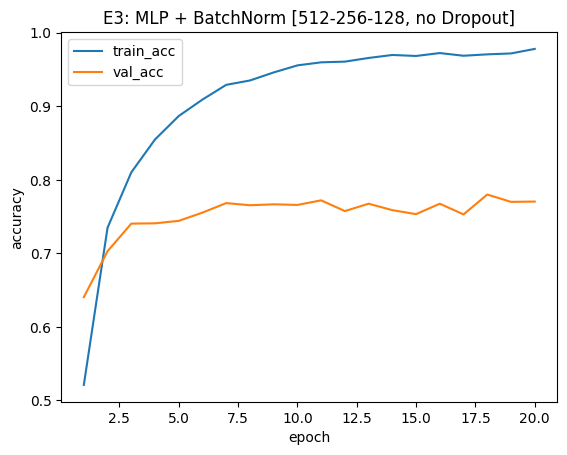

E3 BatchNorm test: loss=0.8974, acc=0.7660
E3: runs.csv обновлен


In [10]:
# E3 (BatchNorm)
set_seed(42)
bn_model = MLP(
    input_shape=(1, 28, 28),        # EMNIST
    num_classes=47,                 # balanced  
    hidden_sizes=[512, 256, 128],   # MLP 
    dropout=0.0,                    # без Dropout 
    use_batchnorm=True              # BatchNorm
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,                      # фиксированные 20 эпох (как E1)
    early_stopping=None
)

plot_history(history_bn, title="E3: MLP + BatchNorm [512-256-128, no Dropout]")
test_metrics_e3 = evaluate(bn_model, test_loader, criterion, device)
print(f"E3 BatchNorm test: loss={test_metrics_e3['loss']:.4f}, acc={test_metrics_e3['acc']:.4f}")

save_experiment_artifacts(
    experiment_id="E3",
    model=bn_model,
    history=history_bn,
    dataset_name="EMNIST_balanced",
    seed=42,
    hidden_sizes=[512, 256, 128],
    dropout=0.0,
    use_batchnorm=True,
    optimizer_name="Adam", 
    lr=1e-3
)

Более эффективная модель согласно метрике vallidation accuracy E2 - MLP+ Dropout без BatchNorm

In [11]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

epoch 01/50 | train loss=2.1995, acc=0.5210 | val loss=1.4640, acc=0.6404
epoch 02/50 | train loss=1.0516, acc=0.7349 | val loss=1.0441, acc=0.7029
epoch 03/50 | train loss=0.6817, acc=0.8101 | val loss=0.8936, acc=0.7404
epoch 04/50 | train loss=0.4939, acc=0.8549 | val loss=0.8149, acc=0.7408
epoch 05/50 | train loss=0.3740, acc=0.8868 | val loss=0.7889, acc=0.7442
epoch 06/50 | train loss=0.2934, acc=0.9092 | val loss=0.7475, acc=0.7554
epoch 07/50 | train loss=0.2392, acc=0.9292 | val loss=0.7433, acc=0.7683
epoch 08/50 | train loss=0.2033, acc=0.9351 | val loss=0.7691, acc=0.7654
epoch 09/50 | train loss=0.1701, acc=0.9460 | val loss=0.7537, acc=0.7667
epoch 10/50 | train loss=0.1409, acc=0.9556 | val loss=0.8041, acc=0.7658
epoch 11/50 | train loss=0.1260, acc=0.9598 | val loss=0.7951, acc=0.7721
epoch 12/50 | train loss=0.1182, acc=0.9607 | val loss=0.8221, acc=0.7575
epoch 13/50 | train loss=0.1048, acc=0.9657 | val loss=0.8143, acc=0.7675
epoch 14/50 | train loss=0.0920, acc=0

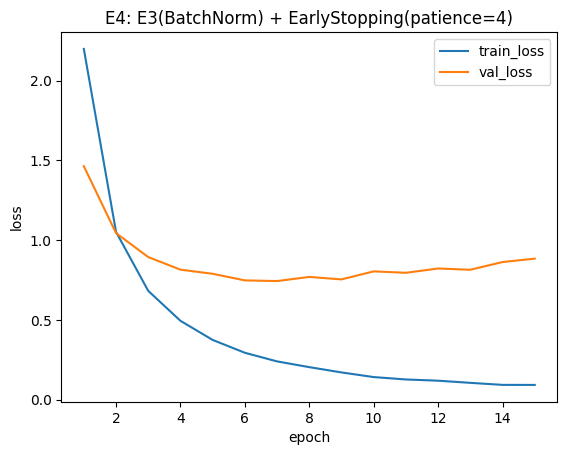

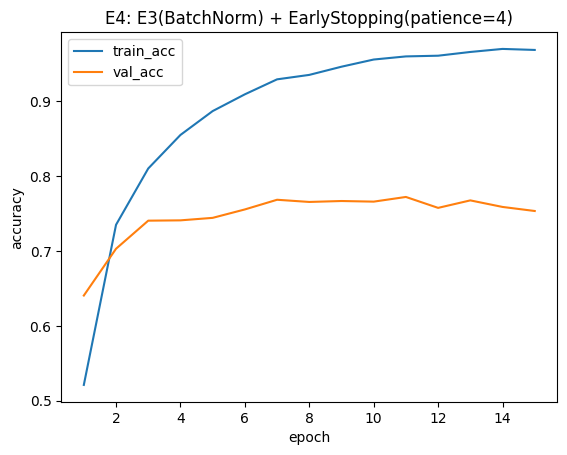

E4 test: loss=0.8188, acc=0.7643
E4: runs.csv обновлен
E4: best_model.pt + best_config.json сохранены
E4: artifacts\figures\curves_best.png сохранен!


In [12]:
set_seed(42)

# E4: ЛУЧШИЙ ИЗ E2/E3 (E3 BatchNorm) + EarlyStopping (patience=4)
e4_model = MLP(
    input_shape=(1, 28, 28),
    num_classes=47,
    hidden_sizes=[512, 256, 128],   
    dropout=0.0,                   
    use_batchnorm=True             
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(e4_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_e4 = fit(
    e4_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,
    early_stopping=es,
    verbose=True
)

plot_history(history_e4, title="E4: E3(BatchNorm) + EarlyStopping(patience=4)")

test_metrics = evaluate(e4_model, test_loader, criterion, device)
print(f"E4 test: loss={test_metrics['loss']:.4f}, acc={test_metrics['acc']:.4f}")

# Сохранение артефактов 
save_experiment_artifacts(
    experiment_id="E4",
    model=e4_model,
    history=history_e4,
    es=es,
    test_metrics=test_metrics,
    dataset_name="EMNIST_balanced",
    seed=42,
    hidden_sizes=[512, 256, 128],
    dropout=0.0,                    
    use_batchnorm=True,            
    optimizer_name="Adam",
    lr=1e-3
)


3.2. Часть B (S09): LR, оптимизаторы, weight decay

epoch 01/6 | train loss=187.6837, acc=0.0239 | val loss=3.8809, acc=0.0246
epoch 02/6 | train loss=3.8645, acc=0.0210 | val loss=3.8620, acc=0.0221
epoch 03/6 | train loss=3.8606, acc=0.0222 | val loss=3.8670, acc=0.0246
epoch 04/6 | train loss=3.8610, acc=0.0216 | val loss=3.8587, acc=0.0208
epoch 05/6 | train loss=3.8599, acc=0.0243 | val loss=3.8574, acc=0.0221
epoch 06/6 | train loss=3.8594, acc=0.0182 | val loss=3.8611, acc=0.0196


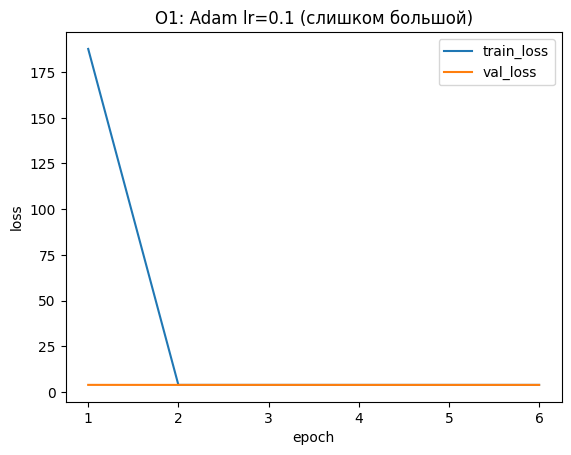

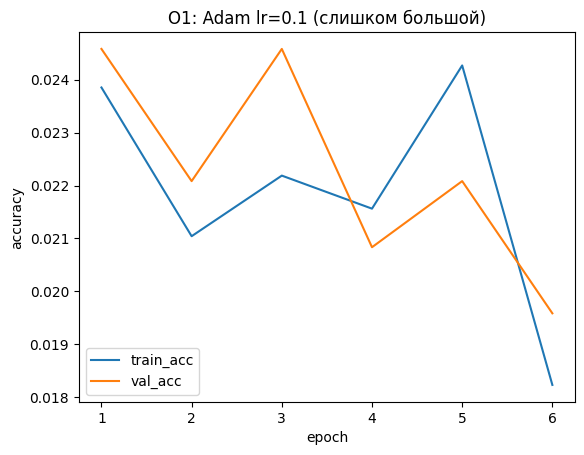

O1 test: loss=3.8631, acc=0.0213
O1: runs.csv обновлен
O1: artifacts\figures\curves_lr_extremes.png сохранен!


In [13]:
set_seed(42)

# O1 (LR слишком большой): Adam lr=1e-1, 6 эпох
o1_model = MLP(
    input_shape=(1, 28, 28),
    num_classes=47,
    hidden_sizes=[512, 256, 128],
    dropout=0.0,
    use_batchnorm=False
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(o1_model.parameters(), lr=1e-1)  # СЛИШКОМ БОЛЬШОЙ LR!

history_o1 = fit(
    o1_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=6,  # ТЗ: 5-8 эпох
    early_stopping=None
)

plot_history(history_o1, title="O1: Adam lr=0.1 (слишком большой)")
test_metrics_o1 = evaluate(o1_model, test_loader, criterion, device)
print(f"O1 test: loss={test_metrics_o1['loss']:.4f}, acc={test_metrics_o1['acc']:.4f}")

save_experiment_artifacts(
    experiment_id="O1",
    model=o1_model,
    history=history_o1,
    dataset_name="EMNIST_balanced",
    seed=42,
    hidden_sizes=[512, 256, 128],
    dropout=0.0,
    use_batchnorm=False,
    optimizer_name="Adam",
    lr=1e-1 
)

epoch 01/6 | train loss=3.8433, acc=0.0238 | val loss=3.8355, acc=0.0296
epoch 02/6 | train loss=3.8235, acc=0.0462 | val loss=3.8133, acc=0.0604
epoch 03/6 | train loss=3.7955, acc=0.0772 | val loss=3.7812, acc=0.0992
epoch 04/6 | train loss=3.7566, acc=0.1151 | val loss=3.7374, acc=0.1354
epoch 05/6 | train loss=3.7047, acc=0.1442 | val loss=3.6802, acc=0.1471
epoch 06/6 | train loss=3.6388, acc=0.1595 | val loss=3.6098, acc=0.1642


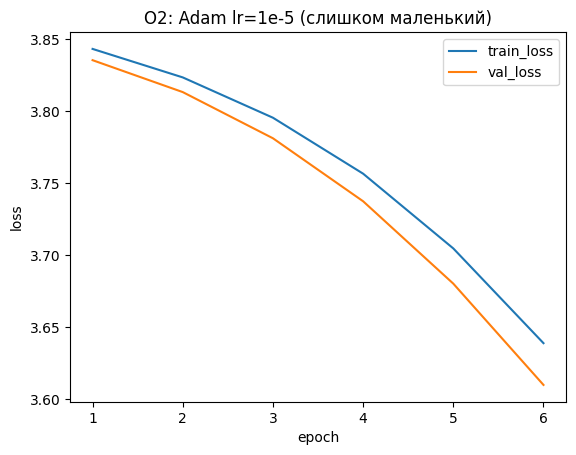

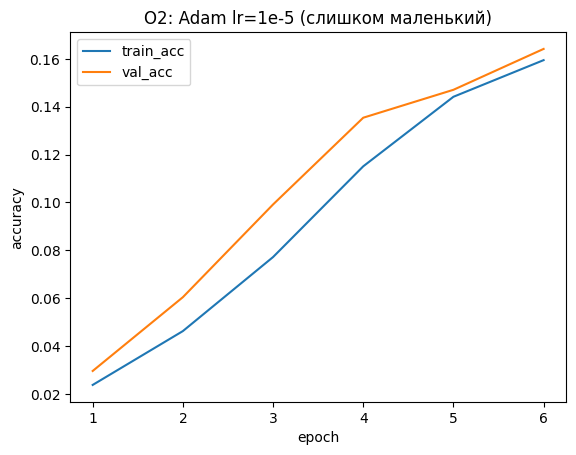

O2 test: loss=3.6125, acc=0.1477
O2: runs.csv обновлен
O2: artifacts\figures\curves_lr_extremes2.png сохранен!


In [14]:
set_seed(42)

# O2 (LR слишком маленький): Adam lr=1e-5, 6 эпох
o2_model = MLP(
    input_shape=(1, 28, 28),
    num_classes=47,
    hidden_sizes=[512, 256, 128],
    dropout=0.0,
    use_batchnorm=False
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(o2_model.parameters(), lr=1e-5)  # СЛИШКОМ МАЛЕНЬКИЙ LR!

history_o2 = fit(
    o2_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=6,  # ТЗ: 5-8 эпох
    early_stopping=None
)

plot_history(history_o2, title="O2: Adam lr=1e-5 (слишком маленький)")
test_metrics_o2 = evaluate(o2_model, test_loader, criterion, device)
print(f"O2 test: loss={test_metrics_o2['loss']:.4f}, acc={test_metrics_o2['acc']:.4f}")

save_experiment_artifacts(
    experiment_id="O2",
    model=o2_model,
    history=history_o2,
    dataset_name="EMNIST_balanced",
    seed=42,
    hidden_sizes=[512, 256, 128],
    dropout=0.0,
    use_batchnorm=False,
    optimizer_name="Adam",
    lr=1e-5 
)

epoch 01/12 | train loss=3.8157, acc=0.0564 | val loss=3.7483, acc=0.0929
epoch 02/12 | train loss=3.3820, acc=0.1673 | val loss=2.7684, acc=0.2542
epoch 03/12 | train loss=2.2164, acc=0.3785 | val loss=1.7813, acc=0.4879
epoch 04/12 | train loss=1.6361, acc=0.5205 | val loss=1.5659, acc=0.5375
epoch 05/12 | train loss=1.4198, acc=0.5869 | val loss=1.3832, acc=0.5950
epoch 06/12 | train loss=1.2673, acc=0.6304 | val loss=1.2654, acc=0.6196
epoch 07/12 | train loss=1.1460, acc=0.6565 | val loss=1.2144, acc=0.6283
epoch 08/12 | train loss=1.0529, acc=0.6834 | val loss=1.1495, acc=0.6588
epoch 09/12 | train loss=0.9687, acc=0.7036 | val loss=1.0597, acc=0.6800
epoch 10/12 | train loss=0.8884, acc=0.7294 | val loss=1.0454, acc=0.6821
epoch 11/12 | train loss=0.8356, acc=0.7371 | val loss=1.0074, acc=0.6804
epoch 12/12 | train loss=0.7563, acc=0.7582 | val loss=0.9388, acc=0.7008


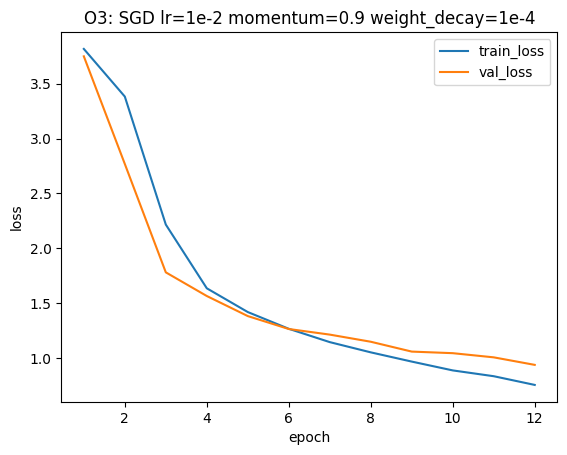

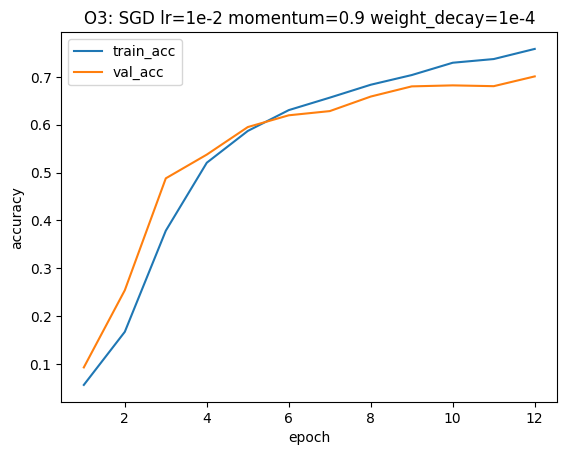

O3 test: loss=0.9425, acc=0.7103
O3: runs.csv обновлен


In [15]:
set_seed(42)

# O3 (SGD+momentum+weight_decay): lr=1e-2, momentum=0.9, weight_decay=1e-4
o3_model = MLP(
    input_shape=(1, 28, 28),
    num_classes=47,
    hidden_sizes=[512, 256, 128],
    dropout=0.0,
    use_batchnorm=False
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(o3_model.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)  # SGD!

history_o3 = fit(
    o3_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=12,  # ТЗ: 10-15 эпох
    early_stopping=None
)

plot_history(history_o3, title="O3: SGD lr=1e-2 momentum=0.9 weight_decay=1e-4")
test_metrics_o3 = evaluate(o3_model, test_loader, criterion, device)
print(f"O3 test: loss={test_metrics_o3['loss']:.4f}, acc={test_metrics_o3['acc']:.4f}")

save_experiment_artifacts(
    experiment_id="O3",
    model=o3_model,
    history=history_o3,
    dataset_name="EMNIST_balanced",
    seed=42,
    hidden_sizes=[512, 256, 128],
    dropout=0.0,
    use_batchnorm=False,
    optimizer_name="SGD",
    lr=1e-2,
    momentum=0.9,
    weight_decay=1e-4
)


In [16]:
model = MLP(input_shape=(1,28,28), num_classes=47, hidden_sizes=[512,256,128], 
            dropout=0.0, use_batchnorm=True).to(device)
model.load_state_dict(torch.load("artifacts/best_model.pt", weights_only=True))
criterion = nn.CrossEntropyLoss()
test_metrics = evaluate(model, test_loader, criterion, device)
print(f"E4 FINAL test_accuracy: {test_metrics['acc']:.4f}")

E4 FINAL test_accuracy: 0.7643
